## Pipeline NLP complet — TF-IDF · TensorFlow · FastAPI 


### Partie 1 — Chargement et exploration

#### 1.1 Chargement et constitution du corpus de titres

In [25]:
import re
import time
import string
import warnings
from pathlib import Path
from collections import Counter

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
)

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, Bidirectional, LSTM, TextVectorization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import nltk
from nltk.corpus import stopwords

import spacy

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style='whitegrid')

In [26]:
PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == 'notebook' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
MODELS_DIR = PROJECT_ROOT / 'models'
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = DATA_DIR / 'news.csv'  # Kaggle dataset
CLEAN_CSV_PATH = DATA_DIR / 'titles_clean.csv'
BEST_MODEL_PATH = MODELS_DIR / 'best_model.keras'
VECTORIZER_PATH = MODELS_DIR / 'vectorizer.pkl'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('CSV attendu   =', CSV_PATH)

PROJECT_ROOT = c:\Users\Administrateur\Desktop\ecf\Prediction-Fake-news-Project
CSV attendu   = c:\Users\Administrateur\Desktop\ecf\Prediction-Fake-news-Project\data\news.csv


In [27]:
# fonction load_titles applique strictement les regles demandees:
# - selection/renommage de colonnes
# - mapping `REAL -> 1` et `FAKE -> 0`
# - suppression des titres vides
# - resume statistique

def load_titles(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath)
    if not {'title', 'label'}.issubset(df.columns):
        raise ValueError('Le CSV doit contenir les colonnes title et label.')

    out = df[['title', 'label']].copy()
    out = out.rename(columns={'title': 'text', 'label': 'label'})
    out['label'] = out['label'].map({'REAL': 1, 'FAKE': 0})

    out['text'] = out['text'].astype(str)
    out['text'] = out['text'].str.strip()
    out = out[out['text'].notna()]
    out = out[out['text'] != '']
    out = out[out['label'].isin([0, 1])].reset_index(drop=True)

    lengths = out['text'].str.split().apply(len)
    class_counts = out['label'].value_counts().sort_index()
    class_props = out['label'].value_counts(normalize=True).sort_index().round(4)

    print('Nb titres total :', len(out))
    print('Nb par classe   :', class_counts.to_dict(), '(FAKE=0, 1=REAL)')
    print('Proportions     :', class_props.to_dict())
    print('Longueur moyenne:', round(lengths.mean(), 2), 'tokens')

    return out

In [28]:
df = load_titles(str(CSV_PATH))
df.to_csv(CLEAN_CSV_PATH, index=False)
print('Fichier nettoye initial sauvegarde ->', CLEAN_CSV_PATH)
df.head()

Nb titres total : 6335
Nb par classe   : {0: 3164, 1: 3171} (FAKE=0, 1=REAL)
Proportions     : {0: 0.4994, 1: 0.5006}
Longueur moyenne: 10.5 tokens
Fichier nettoye initial sauvegarde -> c:\Users\Administrateur\Desktop\ecf\Prediction-Fake-news-Project\data\titles_clean.csv


,text,label
0,You Can Smell Hillary’s Fear,0
1,Watch The Exact Moment Paul Ryan Committed Pol...,0
2,Kerry to go to Paris in gesture of sympathy,1
3,Bernie supporters on Twitter erupt in anger ag...,0
4,The Battle of New York: Why This Primary Matters,1


#### 1.2 Analyse exploratoire

label
1    3171
0    3164
Name: count, dtype: int64
Real: 3171 messages (50.1%)
Fake: 3164 messages (49.9%)
Ratio Real/Fake: 1.00:1


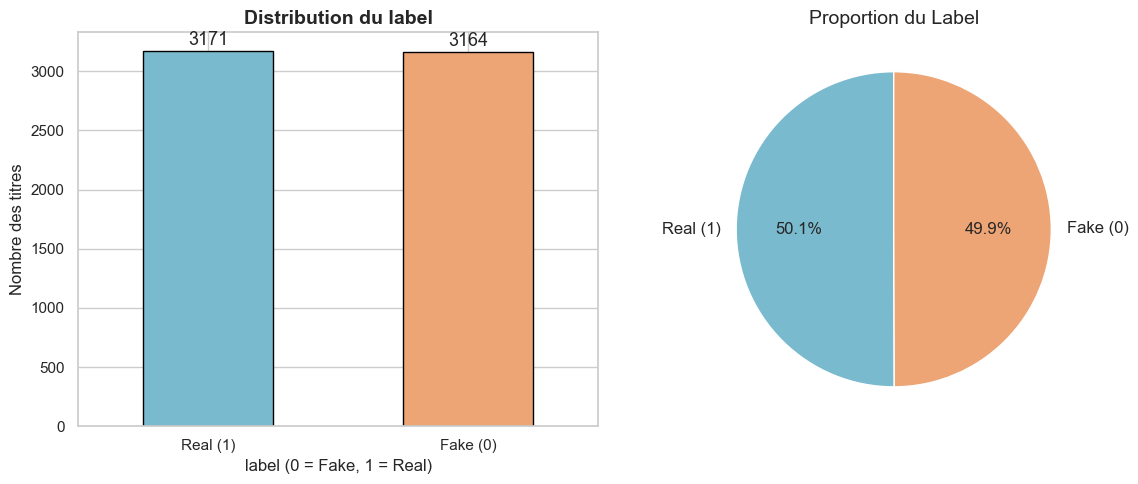


Fake titres : 3164 (49.9%)

Real titres : 3171 (50.1%)


In [29]:
# - Distribution des classes : le corpus est-il équilibré ? Si non, quelle stratégie envisagez-vous ?

print(df['label'].value_counts())

# Analyse du déséquilibre
fake_count = (df['label'] == 0).sum()
real_count = (df['label'] == 1).sum()
ratio = real_count / fake_count

print(f"Real: {real_count} messages ({real_count/len(df)*100:.1f}%)")
print(f"Fake: {fake_count} messages ({fake_count/len(df)*100:.1f}%)")
print(f"Ratio Real/Fake: {ratio:.2f}:1")


# Distribution de la variable cible

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Diagramme en barres
churn_counts = df['label'].value_counts()
colors = ["#7ABACE", "#EEA575"]
churn_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Distribution du label', fontsize=14, fontweight='bold')
axes[0].set_xlabel('label (0 = Fake, 1 = Real)')
axes[0].set_ylabel('Nombre des titres')
axes[0].set_xticklabels(['Real (1)', 'Fake (0)'], rotation=0)

for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=13)

# Diagramme circulaire
axes[1].pie(churn_counts.values, labels=['Real (1)', 'Fake (0)'], colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proportion du Label', fontsize=14)

plt.tight_layout()
plt.show()

print(f"\nFake titres : {churn_counts[0]} ({churn_counts[0]/len(df)*100:.1f}%)")
print(f"\nReal titres : {churn_counts[1]} ({churn_counts[1]/len(df)*100:.1f}%)")


Pour notre cas , le corpus est pratiquement équilibré : 1 = 50.06% et 0 = 49.94%. La différence est d’environ 0.11 point de pourcentage, donc négligeable.

(Dans le cas de déséquilbre de classe : On compense le déséquilibre en pondérant la loss avec des poids de classes calculés par compute_class_weight avec sklearn.utils.class_weight ,, oversampling, ou seuil adapte)


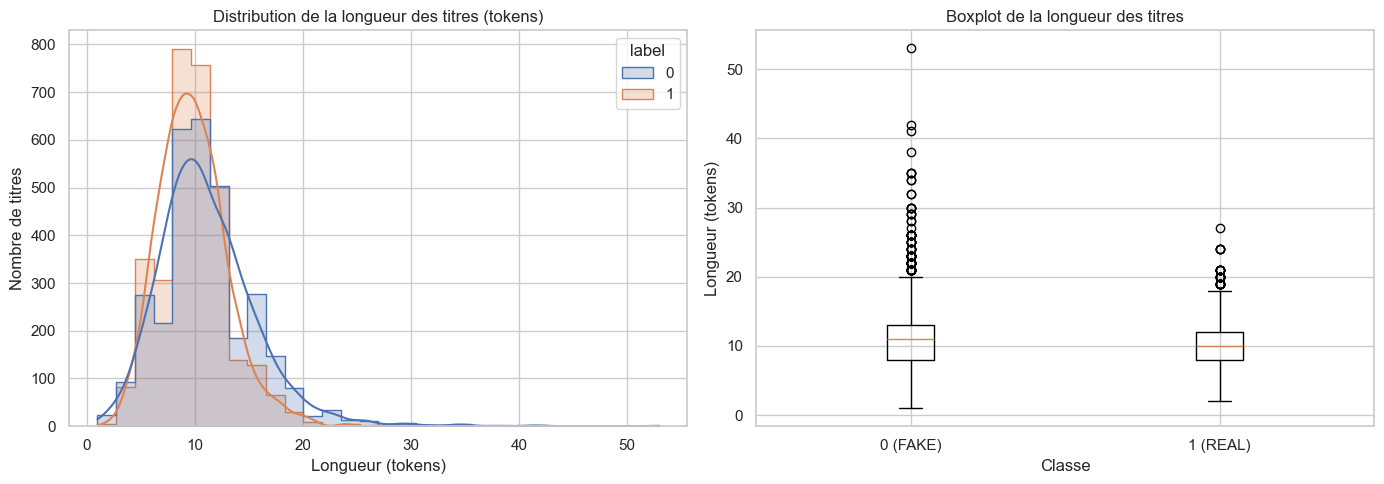

       min  max  median       mean
label                             
0        1   53    11.0  11.133059
1        2   27    10.0   9.861243


In [30]:
# - Distribution de la longueur des titres en tokens : histogramme par classe, valeurs min / max / médiane
df['len_tokens'] = df['text'].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Histogramme par classe
sns.histplot(
    data=df,
    x='len_tokens',
    hue='label',
    bins=30,
    kde=True,
    element='step',
    ax=axes[0]
)
axes[0].set_title("Distribution de la longueur des titres (tokens)")
axes[0].set_xlabel("Longueur (tokens)")
axes[0].set_ylabel("Nombre de titres")

# 2) Boxplot par classe
data_0 = df[df["label"] == 0]["len_tokens"]  
data_1 = df[df["label"] == 1]["len_tokens"]  
axes[1].boxplot([data_0, data_1], labels=["0 (FAKE)", "1 (REAL)"])
axes[1].set_title("Boxplot de la longueur des titres")
axes[1].set_xlabel("Classe")
axes[1].set_ylabel("Longueur (tokens)")

plt.tight_layout()
plt.show()


stats_len = df.groupby('label')['len_tokens'].agg(['min', 'max', 'median', 'mean'])
print(stats_len)





- Les deux classes ont des longueurs de titres proches (médiane 11 pour FAKE vs 10 pour REAL, moyennes 11.13 vs 9.86), donc la longueur seule est un signal faiblement discriminant.
- On observe cependant que les titres FAKE sont en moyenne un peu plus longs et surtout plus dispersés (max=53 contre max=27)

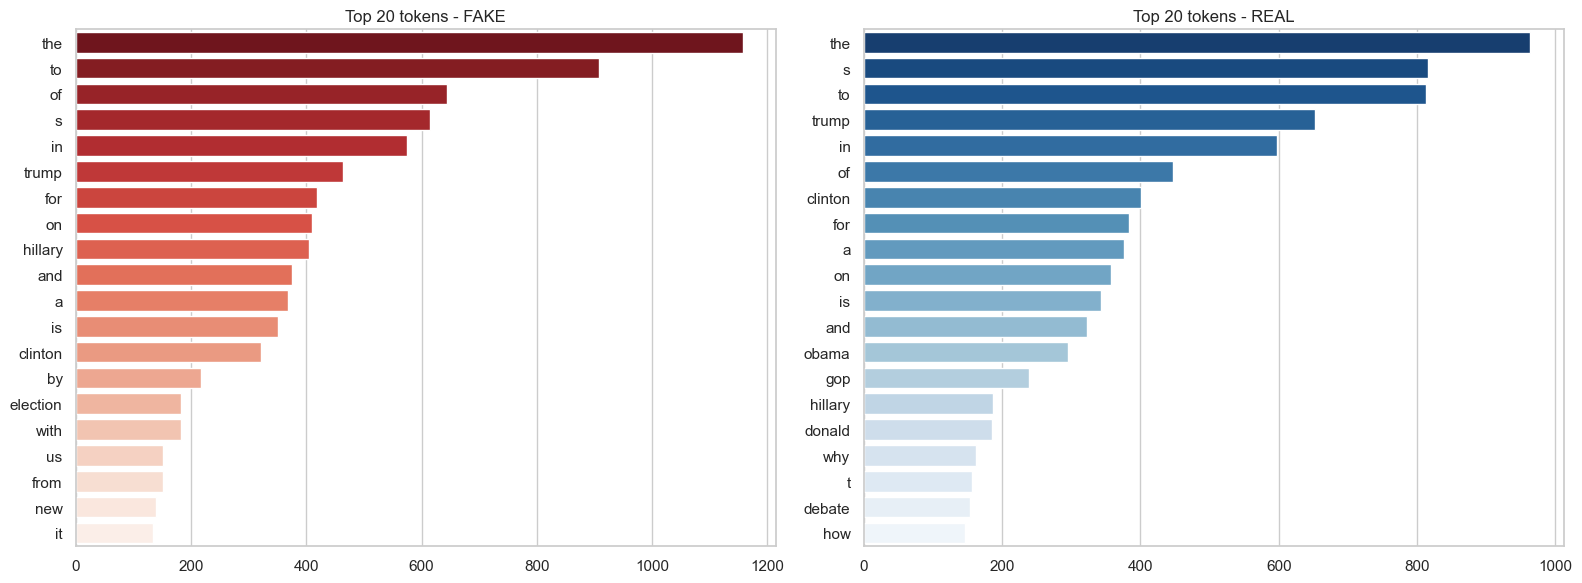

In [31]:
# - Top 20 des tokens les plus fréquents dans chaque classe — affichez deux diagrammes en barres côte à côte

def top_tokens(texts, n=20):
    toks = []
    for t in texts:
        toks.extend(re.findall(r"\b\w+\b", t.lower()))
    return Counter(toks).most_common(n)

top_fake = top_tokens(df[df['label'] == 0]['text'])
top_real = top_tokens(df[df['label'] == 1]['text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=[c for _, c in top_fake], y=[w for w, _ in top_fake], ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 20 tokens - FAKE')
sns.barplot(x=[c for _, c in top_real], y=[w for w, _ in top_real], ax=axes[1], palette='Blues_r')
axes[1].set_title('Top 20 tokens - REAL')
plt.tight_layout()
plt.show()


- Le top tokens brut est dominé par des mots-outils et des artefacts de tokenisation (the, of, s, etc.), présents dans les deux classes.
-  Sans prétraitement, la fréquence brute capture surtout le “bruit de langue” plutôt que les signaux de désinformation.

In [32]:
# Identification des tokens présents dans une seule classe (discriminants purs) : listez les 10 premiers par classe
# pure_fake - pure_real

tokens_fake = set(re.findall(r"\b\w+\b", ' '.join(df[df['label'] == 0]['text']).lower()))
tokens_real = set(re.findall(r"\b\w+\b", ' '.join(df[df['label'] == 1]['text']).lower()))

pure_fake = sorted(tokens_fake - tokens_real)[:10]
pure_real = sorted(tokens_real - tokens_fake)[:10]

print('10 tokens FAKE uniquement :', pure_fake)
print('10 tokens REAL uniquement :', pure_real)

10 tokens FAKE uniquement : ['00', '00pm', '01', '04', '05', '06', '1000', '1000s', '100k', '100percentfedup']
10 tokens REAL uniquement : ['08', '100m', '106', '126', '147', '179', '1980', '1980s', '1990s', '1996']


- sans nettoyage, les “discriminants” sont surtout des nombres/artefacts (00, 100m, 1990s, etc.), pas des mots sémantiquement intéressants.

In [33]:

if "tokens" not in df.columns:
    df["tokens"] = df["text"].str.lower().apply(lambda x: re.findall(r"\b[a-z]{2,}\b", str(x)))

tok = df[["label", "tokens"]].explode("tokens").dropna(subset=["tokens"]).copy()

counts = tok.groupby(["label", "tokens"]).size().reset_index(name="freq")
pivot = counts.pivot(index="tokens", columns="label", values="freq").fillna(0)

if 0 not in pivot.columns:
    pivot[0] = 0
if 1 not in pivot.columns:
    pivot[1] = 0

disc_fake_set = set(pivot[(pivot[0] > 0) & (pivot[1] == 0)].index)  # classe 0
disc_real_set = set(pivot[(pivot[1] > 0) & (pivot[0] == 0)].index)  # classe 1

# Score d'ambiguïté 
tmp = df.copy()
tmp["fake_hits"] = tmp["tokens"].apply(lambda L: sum(t in disc_fake_set for t in L))
tmp["real_hits"] = tmp["tokens"].apply(lambda L: sum(t in disc_real_set for t in L))
tmp["total_hits"] = tmp["fake_hits"] + tmp["real_hits"]
tmp["diff_hits"] = (tmp["fake_hits"] - tmp["real_hits"]).abs()
tmp["len_tokens"] = tmp["tokens"].apply(len)

# 3) Filtre + tri des plus ambigus
ambigus = tmp[
    ((tmp["total_hits"] <= 1) | (tmp["diff_hits"] <= 1)) &
    (tmp["len_tokens"] >= 4)
].copy()

ambigus = ambigus.sort_values(
    by=["total_hits", "diff_hits", "len_tokens"],
    ascending=[True, True, True]
).head(3)

def build_reason(row):
    reasons = []
    if int(row["total_hits"]) == 0:
        reasons.append("aucun token discriminant pur detecte")
    elif int(row["diff_hits"]) <= 1:
        reasons.append("signaux FAKE/REAL presque equilibres")
    if int(row["total_hits"]) <= 1:
        reasons.append("tres peu d'indices lexicaux discriminants")
    return "; ".join(reasons)

if ambigus.empty:
    print("Aucun titre ambigu trouvé avec les critères actuels.")
else:
    for i, (_, row) in enumerate(ambigus.iterrows(), start=1):
        label_txt = "FAKE" if int(row["label"]) == 0 else "REAL"
        reason = build_reason(row)

        print(f"Cas ambigu {i}")
        print(f"Titre : {row['text']}")
        print(f"Label dataset : {label_txt}")
        print(
            f"Indices : fake_hits={int(row['fake_hits'])}, "
            f"real_hits={int(row['real_hits'])}, total_hits={int(row['total_hits'])}"
        )
        print(f"Pourquoi ambigu : {reason}")
        print("-" * 80)



Cas ambigu 1
Titre : How women lead differently
Label dataset : REAL
Indices : fake_hits=0, real_hits=0, total_hits=0
Pourquoi ambigu : aucun token discriminant pur detecte; tres peu d'indices lexicaux discriminants
--------------------------------------------------------------------------------
Cas ambigu 2
Titre : Who had to go :-)
Label dataset : FAKE
Indices : fake_hits=0, real_hits=0, total_hits=0
Pourquoi ambigu : aucun token discriminant pur detecte; tres peu d'indices lexicaux discriminants
--------------------------------------------------------------------------------
Cas ambigu 3
Titre : THE VISION THING 16    : Information
Label dataset : FAKE
Indices : fake_hits=0, real_hits=0, total_hits=0
Pourquoi ambigu : aucun token discriminant pur detecte; tres peu d'indices lexicaux discriminants
--------------------------------------------------------------------------------


## Partie 2 — Nettoyage et prétraitement

### 2.1 Pipeline de nettoyage

une fonction `clean_title(text: str) -> str`
1. Mise en minuscules
2. Suppression des URLs et des mentions de type `@username`
3. Suppression de la ponctuation et des chiffres isolés
4. Expansion des contractions anglaises (`don't` → `do not`, `isn't` → `is not`, etc.) — implémentez un dictionnaire d'au moins 20 contractions courantes
5. Suppression des stopwords anglais (NLTK) **à l'exception** des mots de négation (`not`, `no`, `never`, `neither`) — justifiez ce choix dans une cellule Markdown
6. Lemmatisation avec spaCy (modèle `en_core_web_sm`)
7. Suppression des tokens de longueur inférieure à 2 caractères après lemmatisation

In [34]:
nltk.download("wordnet")
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('omw-1.4')
nltk.download('stopwords')
nlp = spacy.load('en_core_web_sm')
stop_words_en = set(stopwords.words('english'))

CONTRACTIONS = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not", "can't": "can not",
    "couldn't": "could not", "won't": "will not", "wouldn't": "would not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not", "haven't": "have not",
    "hasn't": "has not", "hadn't": "had not", "shouldn't": "should not", "mustn't": "must not",
    "mightn't": "might not", "needn't": "need not", "it's": "it is", "that's": "that is",
    "there's": "there is", "i'm": "i am", "you're": "you are", "they're": "they are"
}
NEGATIONS = {'not', 'no', 'never', 'neither'}

STOPWORDS = stop_words_en - NEGATIONS


def clean_title(text):
    # 1. Convertir en minuscules
    text = text.lower()
    
    # 2.les URLs et kes mentions
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    
    # 3. Remplacer les espaces multiples par un seul
    text = re.sub(r'\s+', ' ', text)

    # Supprimer la ponctuation sauf les apostrophes , chiffres isolés
    text = re.sub(r"[^\w\s']", '', text)
    text = re.sub(r"\b\d\b", " ", text)
    text = text.strip()
    
    # Stopwords 
    for c, e in CONTRACTIONS.items():
        text = re.sub(rf"\b{re.escape(c)}\b", e, text)

    tokens = [w for w in text.split() if w not in STOPWORDS]

    # 6. lemmatisation spaCy
    doc = nlp(" ".join(tokens))
    lemmas = [tok.lemma_ for tok in doc]
    # 7) suppression tokens < 2 caractères
    lemmas = [t for t in lemmas if len(t) >= 2]
    return " ".join(lemmas)

df['text_clean'] = df['text'].apply(clean_title)


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Administrateur\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Administrateur\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Administrateur\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Administrateur\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrateur\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Dans la desinformation, la negation inverse souvent le sens.
- Exemple type: `scientists found evidence` vs `scientists did not find evidence`.
- Exemple type: `vaccine causes illness` vs `vaccine does not cause illness`.
Supprimer `not/no/never/neither` ferait perdre une information semantique critique.

### 2.2 Mesure de l'impact du nettoyage


In [35]:
df['text_clean'] = df['text'].apply(clean_title)

vocab_before = set(' '.join(df['text'].str.lower()).split())
vocab_after = set(' '.join(df['text_clean']).split())
len_before = df['text'].str.split().apply(len)
len_after = df['text_clean'].str.split().apply(len)
empty_after = (df['text_clean'].str.strip() == '').sum()

print('Taille vocab avant  :', len(vocab_before))
print('Taille vocab apres  :', len(vocab_after))
print('Reduction moyenne   :', round((len_before - len_after).mean(), 2), 'tokens')
print('Titres vides apres nettoyage :', int(empty_after))

df = df[df['text_clean'].str.strip() != ''].reset_index(drop=True)
print('Nb lignes conservees apres suppression des vides :', len(df))

Taille vocab avant  : 14454
Taille vocab apres  : 8555
Reduction moyenne   : 2.89 tokens
Titres vides apres nettoyage : 1
Nb lignes conservees apres suppression des vides : 6334


## Partie 3 — Représentation vectorielle

### 3.1 Vectorisation TF-IDF

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text_clean'], df['label'], test_size=0.2, stratify=df['label'], random_state=42
)


vectorize = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = vectorize.fit_transform(X_train)
X_test_tfidf = vectorize.transform(X_test)

joblib.dump(vectorize, VECTORIZER_PATH)
print('Vectoriseur sauvegarde ->', VECTORIZER_PATH)
print('Shape train TF-IDF:', X_train_tfidf.shape)
print('Shape test TF-IDF :', X_test_tfidf.shape)



Vectoriseur sauvegarde -> c:\Users\Administrateur\Desktop\ecf\Prediction-Fake-news-Project\models\vectorizer.pkl
Shape train TF-IDF: (5067, 3000)
Shape test TF-IDF : (1267, 3000)


### 3.2 Embedding avec TensorFlow

In [37]:
max_tokens = 5000
sequence_len = 30

text_vectorizer = TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',
    output_sequence_length=sequence_len,
)

text_vectorizer.adapt(df['text'].values)
print('Vocab max TextVectorization :', max_tokens)

Vocab max TextVectorization : 5000


**Question écrite :** Quelle différence fondamentale y a-t-il entre un vecteur TF-IDF et un vecteur d'embedding appris ? Laquelle de ces deux représentations est capable de capturer que `misleading` et `deceptive` sont sémantiquement proches ? Justifiez.


- TF-IDF encode l'importance statistique d'un terme dans un document vs corpus.
- Embedding appris encode des relations semantiques dans un espace dense.
- C'est l'embedding qui peut rapprocher `misleading` et `deceptive` (proximite semantique).

## Partie 4 — Modélisation

### 4.1 Modèle baseline — réseau dense sur TF-IDF

On entraine 2 architectures demandees puis on compare objectivement les performances.

In [38]:
model_dense = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_tfidf.shape[1],)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_dense.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

callbacks_dense = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    ModelCheckpoint(filepath=str(BEST_MODEL_PATH), save_best_only=True, monitor='val_loss')
]

t0 = time.time()
hist_dense = model_dense.fit(
    X_train_tfidf,
    y_train,
    epochs=30,
    validation_split=0.15,
    callbacks=callbacks_dense,
    verbose=1
)
time_dense = time.time() - t0
print('Temps entrainement dense:', round(time_dense, 2), 's')

Epoch 1/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6329 - loss: 0.6604

OSError: [Errno 22] Invalid argument: 'c:\\Users\\Administrateur\\Desktop\\ecf\\Prediction-Fake-news-Project\\models\\best_model.keras'

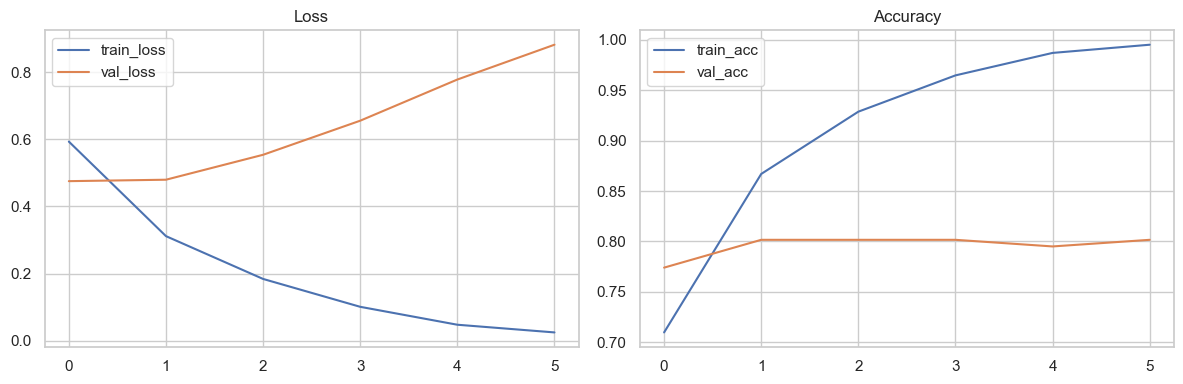

In [ ]:
# les courbes de loss et d'accuracy (train vs validation)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_dense.history['loss'], label='train_loss')
axes[0].plot(hist_dense.history['val_loss'], label='val_loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(hist_dense.history['accuracy'], label='train_acc')
axes[1].plot(hist_dense.history['val_accuracy'], label='val_acc')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

### 4.2 Modèle avec embeddings appris — architecture séquentielle


Le second modèle intégrant la couche `TextVectorization` et une couche `Embedding`

In [ ]:
# Reutilise exactement le meme split que TF-IDF pour une comparaison équitable.
# Keras 3 peut lever "Invalid dtype: object" si on passe des Series pandas brutes.
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()
y_train_raw = y_train.copy()
y_test_raw = y_test.copy()

# Conversion explicite vers les types attendus par Keras.
X_train_raw = X_train_raw.astype(str).to_numpy()
X_test_raw = X_test_raw.astype(str).to_numpy()
y_train_raw = y_train_raw.astype('int32').to_numpy()
y_test_raw = y_test_raw.astype('int32').to_numpy()

model_lstm = Sequential([
    text_vectorizer,
    Embedding(input_dim=5000, output_dim=64, mask_zero=True),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
callbacks_lstm = [EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')]

t0 = time.time()
hist_lstm = model_lstm.fit(
    X_train_raw,
    y_train_raw,
    epochs=30,
    validation_split=0.15,
    callbacks=callbacks_lstm,
    verbose=1
)
time_lstm = time.time() - t0
print('Temps entrainement LSTM:', round(time_lstm, 2), 's')

Epoch 1/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7134 - loss: 0.5568 - val_accuracy: 0.7898 - val_loss: 0.4609
Epoch 2/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8702 - loss: 0.3104 - val_accuracy: 0.8055 - val_loss: 0.4779
Epoch 3/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9176 - loss: 0.2116 - val_accuracy: 0.8016 - val_loss: 0.5887
Epoch 4/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9471 - loss: 0.1522 - val_accuracy: 0.7871 - val_loss: 0.7916
Epoch 5/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9628 - loss: 0.1120 - val_accuracy: 0.7898 - val_loss: 0.8906
Epoch 6/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9691 - loss: 0.0896 - val_accuracy: 0.7727 - val_loss: 0.9523
Temps entrainement LSTM: 17.84 s


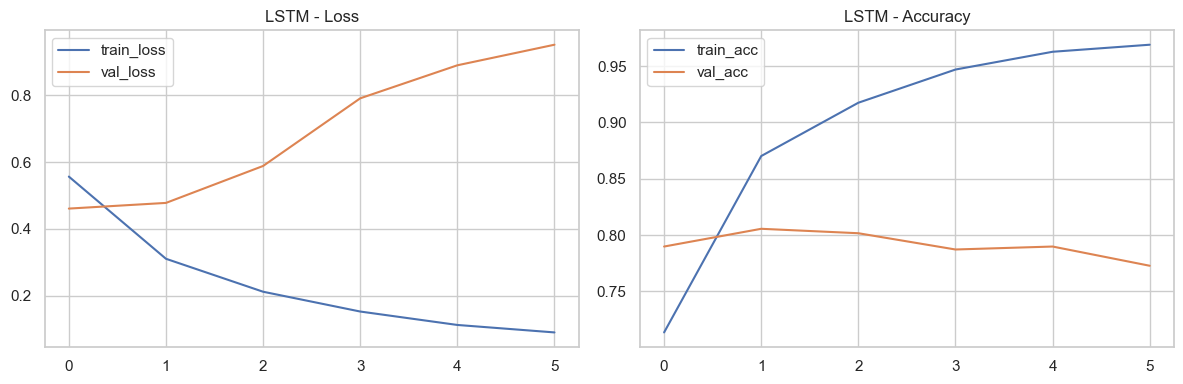

In [ ]:
# Courbes d'apprentissage LSTM
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_lstm.history['loss'], label='train_loss')
axes[0].plot(hist_lstm.history['val_loss'], label='val_loss')
axes[0].set_title('LSTM - Loss')
axes[0].legend()
axes[1].plot(hist_lstm.history['accuracy'], label='train_acc')
axes[1].plot(hist_lstm.history['val_accuracy'], label='val_acc')
axes[1].set_title('LSTM - Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

#

### 4.3 Comparaison des deux architectures


In [ ]:
proba_dense = model_dense.predict(X_test_tfidf, verbose=0).flatten()
pred_dense = (proba_dense >= 0.5).astype(int)

proba_lstm = model_lstm.predict(X_test_raw, verbose=0).flatten()
pred_lstm = (proba_lstm >= 0.5).astype(int)

results = pd.DataFrame([
    {
        'Modele': 'Dense (TF-IDF)',
        'Accuracy (test)': accuracy_score(y_test, pred_dense),
        'Precision FAKE': precision_score(y_test, pred_dense, pos_label=0),
        'Recall FAKE': recall_score(y_test, pred_dense, pos_label=0),
        'F1 macro': f1_score(y_test, pred_dense, average='macro'),
        'AUC-ROC': roc_auc_score(y_test, proba_dense),
        'Epochs effectifs': len(hist_dense.history['loss']),
        'Nb params': model_dense.count_params(),
        'Temps (s)': round(time_dense, 2)
    },
    {
        'Modele': 'BiLSTM (Embedding)',
        'Accuracy (test)': accuracy_score(y_test_raw, pred_lstm),
        'Precision FAKE': precision_score(y_test_raw, pred_lstm, pos_label=0),
        'Recall FAKE': recall_score(y_test_raw, pred_lstm, pos_label=0),
        'F1 macro': f1_score(y_test_raw, pred_lstm, average='macro'),
        'AUC-ROC': roc_auc_score(y_test_raw, proba_lstm),
        'Epochs effectifs': len(hist_lstm.history['loss']),
        'Nb params': model_lstm.count_params(),
        'Temps (s)': round(time_lstm, 2)
    }
])

results

,Modele,Accuracy (test),Precision FAKE,Recall FAKE,F1 macro,AUC-ROC,Epochs effectifs,Nb params,Temps (s)
0,Dense (TF-IDF),0.797948,0.749009,0.895735,0.796026,0.878427,6,801281,3.98
1,BiLSTM (Embedding),0.806630,0.760753,0.894155,0.805161,0.891390,6,394369,17.84


**Question écrite :** Lequel des deux modèles recommanderiez-vous pour une mise en production ? Justifiez votre choix en tenant compte à la fois des performances et des contraintes opérationnelles (temps de réponse, maintenance, volume de données).

Je recommanderais le modèle qui obtient la meilleure performance dans le tableau `results`, en vérifiant aussi le coût opérationnel.

- Si le Dense (TF-IDF)  avec ~0.99 vs ~0.97, il devient le choix naturel pour la mise en production.
- Même quand les scores sont proches, le TF-IDF reste souvent plus simple à maintenir et plus rapide à servir.


## Partie 5 — Évaluation approfondie

### 5.1 Analyse des performances du meilleur modèle

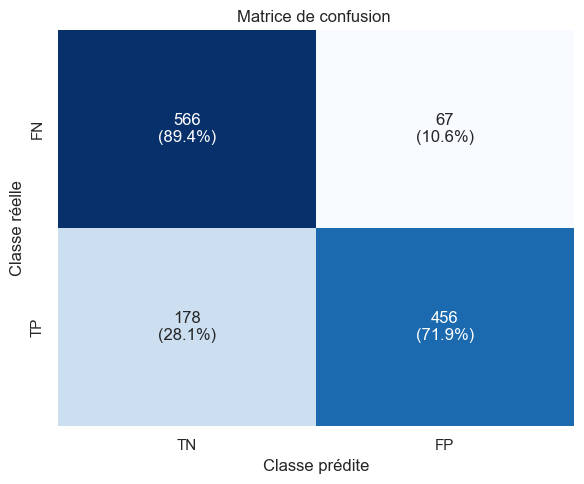

In [ ]:
best_model_name = results.loc[results['Accuracy (test)'].idxmax(), 'Modele']

if best_model_name == 'Dense (TF-IDF)':
    y_true_best = y_test
    y_pred_best = pred_dense
else:
    y_true_best = y_test_raw
    y_pred_best = pred_lstm

cm = confusion_matrix(y_true_best, y_pred_best)  # ordre: [[TN, FP], [FN, TP]]
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
labels = np.array([
    [f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["TN", "FP"],
    yticklabels=["FN", "TP"]
)
plt.title(f"Matrice de confusion ({best_model_name})")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.tight_layout()
plt.show()

In [ ]:
print('Matrice normalisee (%)')
print(np.round(cm_pct * 100, 2))
print('\nClassification report')
print(classification_report(y_true_best, y_pred_best, target_names=['FAKE', 'REAL']))

Matrice normalisee (%)
[[8941.55 1058.45]
 [2807.57 7192.43]]

Classification report
              precision    recall  f1-score   support

        FAKE       0.76      0.89      0.82       633
        REAL       0.87      0.72      0.79       634

    accuracy                           0.81      1267
   macro avg       0.82      0.81      0.81      1267
weighted avg       0.82      0.81      0.81      1267



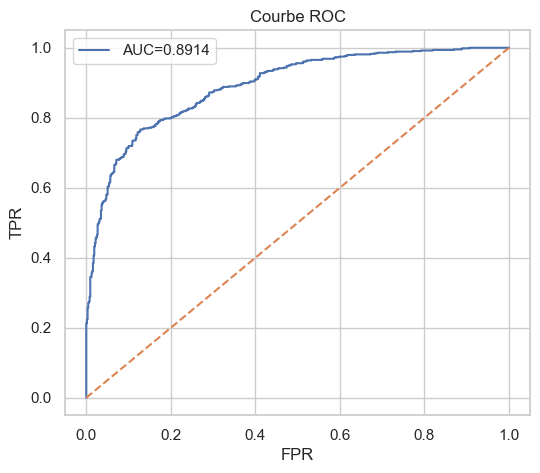

In [ ]:
if best_model_name == 'Dense (TF-IDF)':
    y_prob = proba_dense
    y_pred = pred_dense
else:
    y_prob = proba_lstm
    y_pred = pred_lstm
X_eval_raw = pd.Series(X_test_raw).reset_index(drop=True)

fpr, tpr, _ = roc_curve(y_true_best, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC={roc_auc_score(y_true_best, y_prob):.4f}')
plt.plot([0, 1], [0, 1], '--')
plt.title(f'Courbe ROC ({best_model_name})')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

### 5.2 Analyse des erreurs

In [ ]:
eval_df = pd.DataFrame({
    'title': X_eval_raw.values,
    'y_true': y_true_best,
    'y_prob_real': y_prob,
    'y_pred': y_pred,
})

fp = eval_df[(eval_df['y_true'] == 1) & (eval_df['y_pred'] == 0)].copy()
fp['confidence_wrong'] = 1 - fp['y_prob_real']
fp_top15 = fp.sort_values('confidence_wrong', ascending=False).head(15)

fn = eval_df[(eval_df['y_true'] == 0) & (eval_df['y_pred'] == 1)].copy()
fn['confidence_wrong'] = fn['y_prob_real']
fn_top15 = fn.sort_values('confidence_wrong', ascending=False).head(15)

print('TOP 15 Faux positifs (REAL predit FAKE):')
display(fp_top15[['title', 'y_prob_real', 'confidence_wrong']])

print('TOP 15 Faux negatifs (FAKE predit REAL):')
display(fn_top15[['title', 'y_prob_real', 'confidence_wrong']])

TOP 15 Faux positifs (REAL predit FAKE):


,title,y_prob_real,confidence_wrong
1195,plight bitter nerd many awkward shy guy end ha...,0.032412,0.967588
632,reveal interview trump predict massive recessi...,0.035433,0.964567
230,20000 page hack wikileak email teach we hillar...,0.035915,0.964085
837,heart disease kill way people war murder traff...,0.042310,0.957690
724,high school middle school kid use ecig tobacco...,0.062421,0.937579
994,eric trump charity spend 880k familyowned golf...,0.076402,0.923598
140,penny nance trump vs miss universe can not get...,0.082298,0.917702
583,white kid get medicate misbehave black kid get...,0.092799,0.907201
818,john kasichs advice woman prevent sexual assau...,0.097790,0.902210
690,racism america original sin unless tell truth ...,0.105534,0.894466


TOP 15 Faux negatifs (FAKE predit REAL):


,title,y_prob_real,confidence_wrong
623,police oklahoma double murder suspect hit list...,0.897521,0.897521
1163,erdogan check obama bombing syria,0.890988,0.890988
340,washington 's embargo cuba not effective isola...,0.878953,0.878953
437,republican lawmaker secretly record fantasizin...,0.872315,0.872315
197,hubris democratic elite clinton campaign give ...,0.870976,0.870976
483,trump effect jack box obama 's change,0.863930,0.863930
1227,plan parenthood abortion pill usage rival surgery,0.832455,0.832455
516,memo next administration defense spending must...,0.832022,0.832022
167,disgusting evolution political correctness 200...,0.827867,0.827867
1185,iowa farmer claim bill clinton sex cow cocaine...,0.825392,0.825392


Le modèle est bien performant, mais il reste sensible :

- aux mots déclencheurs (politique, conflit, scandale),
- au style du titre (neutre vs accrocheur),
- et pas uniquement à la véracité réelle du contenu.
- Autrement dit, il apprend surtout des signaux linguistiques de surface dans les titres, ce qui est cohérent avec une tâche “title-only”.

### 5.3 Robustesse


In [ ]:
challenge_titles = [
    'Scientists discover new treatment for common disease',
    'SHOCKING: Government hiding truth about water supply',
    'Local elections results announced in three counties',
    "You won't believe what this celebrity did last night",
    'Central bank raises interest rates by 0.25 points',
    'This one weird trick cures all allergies naturally',
    'Parliament votes on new environmental legislation',
    "Doctors don't want you to know this secret remedy",
    'Tech company reports quarterly earnings below forecast',
    'EXCLUSIVE: Famous actor reveals hidden agenda of elites'
]


challenge_tensor = tf.constant(challenge_titles, dtype=tf.string)
prob_challenge = model_lstm.predict(challenge_tensor, verbose=0).flatten()

robust_df = pd.DataFrame({
    'title': challenge_titles,
    'p_REAL': prob_challenge,
})
robust_df['label_pred'] = np.where(robust_df['p_REAL'] >= 0.5, 'REAL', 'FAKE')
robust_df['confidence'] = np.where(
    robust_df['label_pred'] == 'REAL', robust_df['p_REAL'], 1 - robust_df['p_REAL']
)
robust_df    

,title,p_REAL,label_pred,confidence
0,Scientists discover new treatment for common d...,0.279558,FAKE,0.720442
1,SHOCKING: Government hiding truth about water ...,0.111794,FAKE,0.888206
2,Local elections results announced in three cou...,0.267748,FAKE,0.732252
3,You won't believe what this celebrity did last...,0.585736,REAL,0.585736
4,Central bank raises interest rates by 0.25 points,0.068218,FAKE,0.931782
5,This one weird trick cures all allergies natur...,0.112051,FAKE,0.887949
6,Parliament votes on new environmental legislation,0.320758,FAKE,0.679242
7,Doctors don't want you to know this secret remedy,0.457814,FAKE,0.542186
8,Tech company reports quarterly earnings below ...,0.127225,FAKE,0.872775
9,EXCLUSIVE: Famous actor reveals hidden agenda ...,0.296023,FAKE,0.703977


In [ ]:
# Sauvegarde finale du dataset nettoye (avec text_clean)
df.to_csv(CLEAN_CSV_PATH, index=False)
print('Dataset final sauvegarde ->', CLEAN_CSV_PATH)
print('Modele Dense sauvegarde   ->', BEST_MODEL_PATH)
print('Vectoriseur sauvegarde    ->', VECTORIZER_PATH)

Dataset final sauvegarde -> c:\Users\Administrateur\Desktop\ecf\Prediction-Fake-news-Project\data\titles_clean.csv
Modele Dense sauvegarde   -> c:\Users\Administrateur\Desktop\ecf\Prediction-Fake-news-Project\models\best_model.keras
Vectoriseur sauvegarde    -> c:\Users\Administrateur\Desktop\ecf\Prediction-Fake-news-Project\models\vectorizer.pkl
